# Word2Vec training

This notebook is based on the [word2vec-pytorch](https://github.com/OlgaChernytska/word2vec-pytorch/tree/18d4f24c4d82dde76de9f6e4d88bbcbcf68befc2) repo.

In [1]:
import kagglehub


path = kagglehub.dataset_download("bestwater/wikitext-2-v1")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/bestwater/wikitext-2-v1/versions/1


In [11]:
!mv /root/.cache/kagglehub/datasets/bestwater/wikitext-2-v1/versions/1/wikitext-2 /home/wikitext-2

In [12]:
!ls wikitext-2

wiki.test.tokens  wiki.train.tokens  wiki.valid.tokens


In [2]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams.update({'font.size': 14})

In [3]:
TRAIN_TOKENS = 'wikitext-2/wiki.train.tokens'
VALID_TOKENS = 'wikitext-2/wiki.valid.tokens'

SKIPGRAM_N_WORDS = 4
MIN_WORD_FREQUENCY = 5
MAX_SEQUENCE_LENGTH = 256

EMBED_DIM = 256
EMBED_MAX_NORM = 1
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [4]:
from torchtext.data.utils import get_tokenizer


tokenizer = get_tokenizer("basic_english", language="en")


def load_and_preprocess_dataset(path):
    with open(path, 'r') as file:
        lines = file.readlines()

        print(lines[1001])

    data = list(filter(
        lambda sent: len(sent) > SKIPGRAM_N_WORDS * 2,
        map(tokenizer, lines)
    ))

    return data

In [8]:
train_data = load_and_preprocess_dataset(TRAIN_TOKENS)
valid_data = load_and_preprocess_dataset(VALID_TOKENS)

total_train_tokens = sum(len(sent) for sent in train_data)
total_valid_tokens = sum(len(sent) for sent in valid_data)

print(f'Num sentences: train - {len(train_data)}, valid - {len(valid_data)})')
print(f'Total tokens: train - {total_train_tokens}, valid - {total_valid_tokens})')
print(f'Average tokens in sentence: {total_train_tokens / len(train_data):.2f}')

 = = Original design = = 

 For financial and <unk> reasons the last book was divided into two films , shot back to back , which drew criticism from the series ' fanbase . <unk> defended the split , stating that it would have been impossible to properly adapt the final novel into a single film . He added that the last movie was going to be extremely fast @-@ paced with a lot of action , while the first part would be far more <unk> , focusing on character development ; he added that , had they combined them , those things would not have made it to the final cut . Filming lasted for a year , concluding in June 2010 and on the last day of shooting , like most of the cast and crew , <unk> openly <unk> . 

Num sentences: train - 17715, valid - 1892)
Total tokens: train - 2014338, valid - 211057)
Average tokens in sentence: 113.71


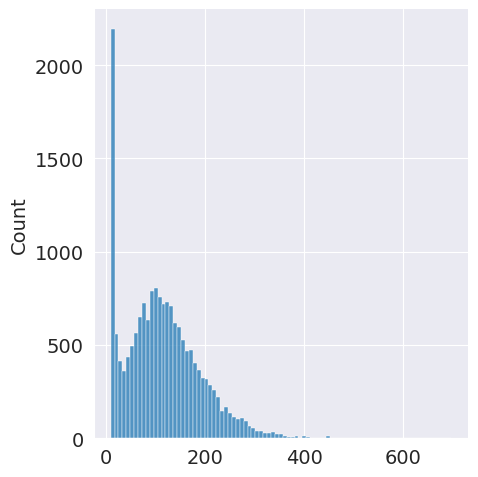

In [9]:
_ = sns.displot([len(sent) for sent in train_data])

In [11]:
from torchtext.vocab import build_vocab_from_iterator


vocab = build_vocab_from_iterator(train_data, specials=["<unk>"], min_freq=MIN_WORD_FREQUENCY)
vocab.set_default_index(vocab["<unk>"])

VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Vocab size: 20323


In [15]:
# train_data[250]

In [14]:
# vocab(train_data[250])

In [19]:
vocab(['president']), vocab(['ewkeryambus']), vocab(['kittty'])

([455], [0], [0])

In [20]:
def collate_fn(batch):
    """
    Collate_fn for Skip-Gram model to be used with Dataloader.
    `batch` is expected to be list of text paragrahs.

    Context is represented as N=SKIPGRAM_N_WORDS past words
    and N=SKIPGRAM_N_WORDS future words.

    Long paragraphs will be truncated to contain
    no more that MAX_SEQUENCE_LENGTH tokens.

    Each element in `batch_input` is a middle word.
    Each element in `batch_output` is a context word.
    """
    batch_input, batch_output = [], []
    for text in batch:
        text_tokens_ids = vocab(text)

        if MAX_SEQUENCE_LENGTH:
            text_tokens_ids = text_tokens_ids[:MAX_SEQUENCE_LENGTH]

        for idx in range(len(text_tokens_ids) - SKIPGRAM_N_WORDS * 2):
            token_id_sequence = text_tokens_ids[idx : (idx + SKIPGRAM_N_WORDS * 2 + 1)]
            input_ = token_id_sequence.pop(SKIPGRAM_N_WORDS)
            outputs = token_id_sequence

            batch_input += [input_] * len(outputs)
            batch_output += outputs

    batch_input = torch.LongTensor(batch_input)
    batch_output = torch.LongTensor(batch_output)

    return batch_input, batch_output

In [22]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    num_workers=8,
    pin_memory=True,
    collate_fn=collate_fn,
    shuffle=True
)

valid_loader = DataLoader(
    valid_data,
    batch_size=BATCH_SIZE,
    num_workers=8,
    pin_memory=True,
    collate_fn=collate_fn,
    shuffle=False
)

In [23]:
next(iter(train_loader))

[tensor([1257, 1257, 1257,  ..., 4636, 4636, 4636]),
 tensor([   28,    28,    28,  ...,  4595, 15776,     2])]

In [24]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        optimizer.step()

    return total_loss / len(data_loader)

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

In [27]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

In [28]:
from torch import nn


class Word2VecModel(nn.Module):
    def __init__(self, embed_dim, embed_max_norm, vocab_size):
        super().__init__()

        self.embeds = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            max_norm=embed_max_norm
        )

        self.decoder = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        return self.decoder(self.embeds(x))

In [29]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

loss_fn = nn.CrossEntropyLoss()

cuda:0


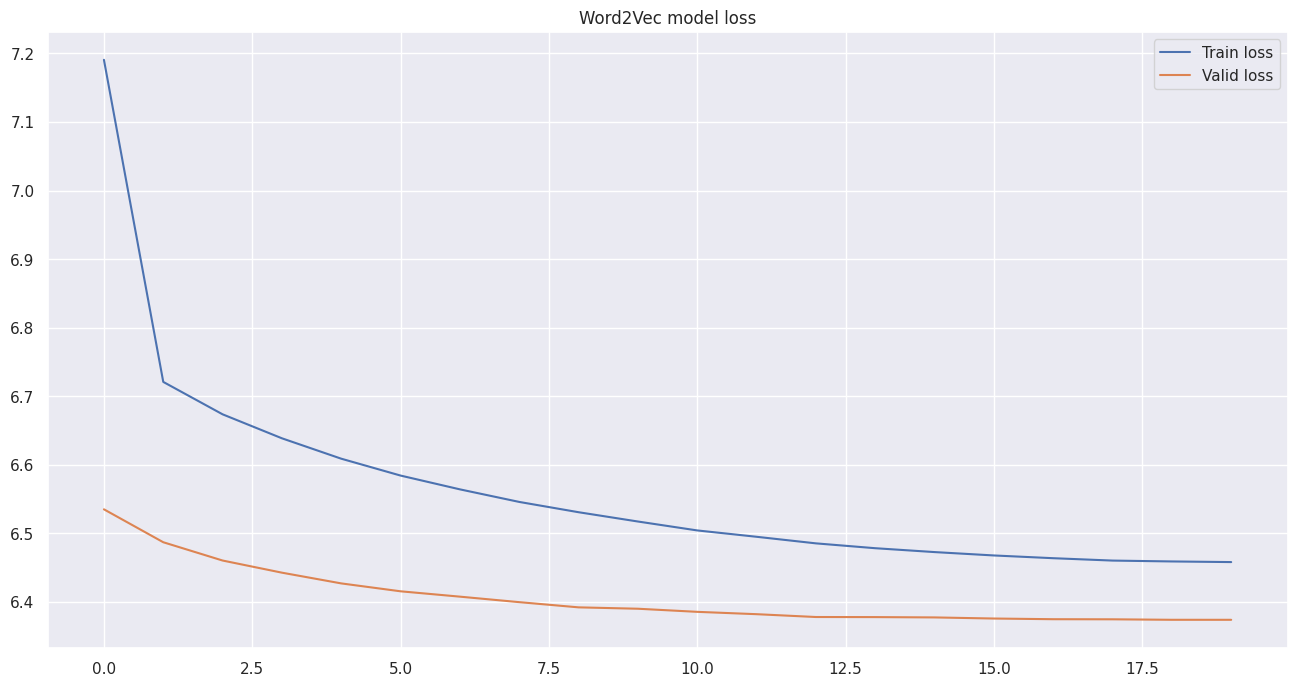

In [20]:
model = Word2VecModel(
    embed_dim=EMBED_DIM,
    embed_max_norm=EMBED_MAX_NORM,
    vocab_size=VOCAB_SIZE
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, NUM_EPOCHS, 'Word2Vec model', scheduler)

In [21]:
torch.save(model.state_dict(), "word2vec.pt")

In [30]:
model = Word2VecModel(
    embed_dim=EMBED_DIM,
    embed_max_norm=EMBED_MAX_NORM,
    vocab_size=VOCAB_SIZE
).to(device)

In [31]:
model.load_state_dict(torch.load("word2vec.pt"))

<All keys matched successfully>

In [32]:
import re


def get_similarities(embed_vector):
    similarities = embed_matrix @ embed_vector / embed_norms / torch.norm(embed_vector)
    top_indices = similarities.argsort(descending=True)
    return similarities, top_indices


def get_similar(query, num_similar=5):
    print(f'Processing query \"{query}\"')
    split_query = re.split('([^a-zA-Z0-9])', query)
    index = vocab[split_query[0]]
    embed_vector = torch.clone(embed_matrix[index])
    if index > 0:
        print(f'Found word \"{split_query[0]}\" in vocab')
    else:
        print(f'Word \"{split_query[0]}\" not in vocab, using <unk>')

    for i in range(2, len(split_query), 2):
        index = vocab[split_query[i]]
        if index > 0:
            print(f'Found word \"{split_query[i]}\" in vocab, ', end='')
        else:
            print(f'Word \"{split_query[i]}\" not in vocab, using <unk>, ', end='')
        print(f'operation \"{split_query[i - 1]}\"')

        if split_query[i - 1] == '+':
            embed_vector += embed_matrix[index]
        elif split_query[i - 1] == '-':
            embed_vector -= embed_matrix[index]
        else:
            raise ValueError('Unknown operation')

    similarities, top_indices = get_similarities(embed_vector)

    itos = vocab.get_itos()
    print('Top similar:')
    for top_index in top_indices[:num_similar]:
        print(f'    {itos[top_index]}: sim = {similarities[top_index]:.4f}')

In [34]:
embed_matrix = model.embeds.weight.detach().cpu()
embed_norms = (embed_matrix ** 2).sum(1).sqrt()

In [35]:
get_similar('woman')

Processing query "woman"
Found word "woman" in vocab
Top similar:
    woman: sim = 1.0000
    girl: sim = 0.7848
    man: sim = 0.7125
    herself: sim = 0.7123
    jealous: sim = 0.7093


In [36]:
get_similar('kick')

Processing query "kick"
Found word "kick" in vocab
Top similar:
    kick: sim = 1.0000
    touchdown: sim = 0.8375
    ecu: sim = 0.8214
    punt: sim = 0.8153
    tech: sim = 0.7989


In [28]:
get_similar('help')

Processing query "help"
Found word "help" in vocab
Top similar:
    help: sim = 1.0000
    keep: sim = 0.6806
    meet: sim = 0.6736
    try: sim = 0.6718
    expel: sim = 0.6651


In [29]:
get_similar('bread')

Processing query "bread"
Found word "bread" in vocab
Top similar:
    bread: sim = 1.0000
    cheese: sim = 0.7273
    widows: sim = 0.6450
    dole: sim = 0.5658
    photographed: sim = 0.5477


In [37]:
v = get_similar('king-man+woman', num_similar=10)

Processing query "king-man+woman"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
Found word "woman" in vocab, operation "+"
Top similar:
    king: sim = 0.8015
    hairan: sim = 0.6969
    son: sim = 0.6777
    amlaíb: sim = 0.6700
    eldest: sim = 0.6667
    narasimha: sim = 0.6658
    veera: sim = 0.6591
    ballala: sim = 0.6582
    lord: sim = 0.6493
    nephew: sim = 0.6461


In [38]:
get_similar('man+brain')

Processing query "man+brain"
Found word "man" in vocab
Found word "brain" in vocab, operation "+"
Top similar:
    man: sim = 0.8615
    brain: sim = 0.8615
    bearded: sim = 0.7291
    mega: sim = 0.7142
    boss: sim = 0.6964


In [41]:
get_similar('king+russia')

Processing query "king+russia"
Found word "king" in vocab
Found word "russia" in vocab, operation "+"
Top similar:
    king: sim = 0.8497
    russia: sim = 0.8497
    ballala: sim = 0.7757
    narasimha: sim = 0.7715
    veera: sim = 0.7678


# FastText for sentiment classification

In [42]:
!kaggle datasets download -d shivkumarganesh/bumble-dating-app-google-play-store-review -p /home
!unzip bumble-dating-app-google-play-store-review.zip

Archive:  bumble-dating-app-google-play-store-review.zip
  inflating: bumble_google_play_reviews.csv  


In [42]:
import pandas as pd
import fasttext
import fasttext.util

In [43]:
fasttext.util.download_model('en')
ft = fasttext.load_model('cc.en.300.bin')

File exists. Use --overwrite to download anyway.


In [44]:
ft.get_word_vector('mother').shape

(300,)

In [58]:
data.content[4]

"Pay money to find out who likes you.frig off trying to find love here limited likes they don't feed you people who swiped on you already blurred until you pay I've swiped lots and they should all ready be part of the next suggestions."

In [52]:
data = pd.read_csv('/home/bumble_google_play_reviews.csv')
data = data[data.content.notna()]
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,395888dc-c8b0-457d-a91e-8a90caf2f2d3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Fake,1,1,5.395.0,2024-11-23 23:41:33,NaN,NaN,5.395.0
1,ed4fcee5-8614-4d1a-98bf-ff22f7b3261a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I h haven't received any responses yet I'm hav...,3,0,5.395.0,2024-11-23 23:16:54,We're sorry to hear about your negative experi...,2024-11-24 08:45:30,5.395.0
2,4afcabd0-103d-47b9-a39a-b81554f556d2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Scam. By the time you're (not) explaining how ...,1,0,5.395.0,2024-11-23 23:01:39,"We’re sorry your experience wasn’t positive, D...",2024-11-23 22:56:00,5.395.0
3,541fde8b-8a55-46a9-b2b3-2445f06d3ba1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,On registration when I reach at stage of A qui...,3,0,5.395.0,2024-11-23 22:09:04,This shouldn't be happening and sounds like so...,2024-11-24 08:45:00,5.395.0
4,fddb7ba9-54ca-410b-9707-247347d9ff98,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Pay money to find out who likes you.frig off t...,1,2,5.395.0,2024-11-23 21:47:56,You don't need to spend any money to match wit...,2024-11-24 08:44:29,5.395.0
...,...,...,...,...,...,...,...,...,...,...,...
160107,61bc7cdc-3085-4631-ac95-d8e42e2e0742,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally here!,5,54,1.0.1,2015-12-01 02:17:24,NaN,NaN,1.0.1
160108,24d07489-88ad-496a-80ce-8f137c130323,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Finally!,5,75,1.0.1,2015-12-01 02:09:05,NaN,NaN,1.0.1
160109,22a42d0d-7a12-400d-a2af-826f35d21581,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Finally, an app where women have to start the ...",4,2,1.0.1,2015-12-01 00:18:53,NaN,NaN,1.0.1
160110,2480a41f-8863-4948-9f83-7d856bd9dc78,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,At last we have Android version!,5,60,1.0.0,2015-11-30 21:27:51,NaN,NaN,1.0.0


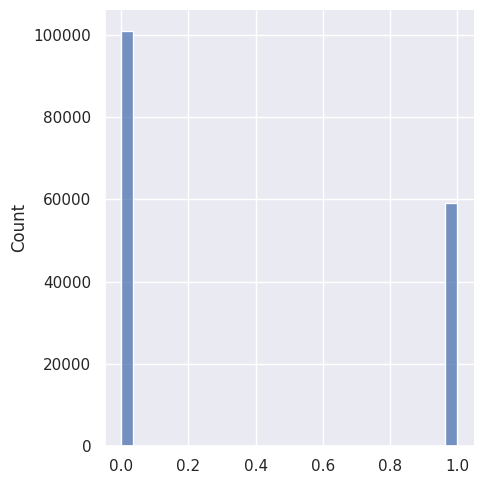

In [59]:
X = data.content.apply(tokenizer).to_list()
y = (data.score >= 4).to_numpy().astype(int)
_ = sns.displot(y)

In [61]:
X[:10]

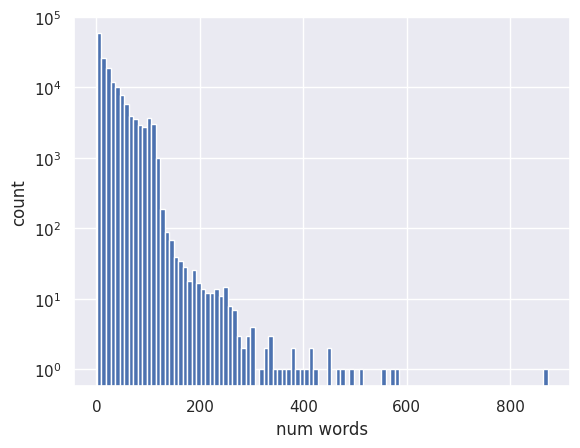

In [62]:
plt.hist([len(sent) for sent in X], bins=100)
plt.yscale('log')
plt.ylabel('count')
plt.xlabel('num words')
plt.show()

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=3407)
len(X_train), len(X_valid)

(120072, 40024)

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [65]:
X_train_sents = [' '.join(sent) for sent in X_train]
X_valid_sents = [' '.join(sent) for sent in X_valid]

In [66]:
tf_idf = TfidfVectorizer(min_df=5).fit(X_train_sents)
tf_idf_train = tf_idf.transform(X_train_sents)
tf_idf_valid = tf_idf.transform(X_valid_sents)

tf_idf_train.shape, tf_idf_valid.shape

((120072, 9076), (40024, 9076))

In [69]:
lr = LogisticRegression(max_iter=1000).fit(tf_idf_train, y_train)

In [70]:
print(f'Tf-idf + LogRegr train acc: {accuracy_score(lr.predict(tf_idf_train), y_train):.4f}')
print(f'Tf-idf + LogRegr valid acc: {accuracy_score(lr.predict(tf_idf_valid), y_valid):.4f}')

Tf-idf + LogRegr train acc: 0.9012
Tf-idf + LogRegr valid acc: 0.8918


In [71]:
def get_sentence_embedding(sent):
    embeds = []
    for word in sent:
        embeds += [ft.get_word_vector(word)]

    return np.stack(embeds, axis=0).mean(0)

In [72]:
train_embeds = np.stack([get_sentence_embedding(sent) for sent in X_train], axis=0)
valid_embeds = np.stack([get_sentence_embedding(sent) for sent in X_valid], axis=0)

In [73]:
train_embeds.shape

(120072, 300)

In [74]:
lr = LogisticRegression(max_iter=1000).fit(train_embeds, y_train)

In [75]:
print(f'FastText + LogRegr train acc: {accuracy_score(lr.predict(train_embeds), y_train):.4f}')
print(f'FastText + LogRegr valid acc: {accuracy_score(lr.predict(valid_embeds), y_valid):.4f}')

FastText + LogRegr train acc: 0.8600
FastText + LogRegr valid acc: 0.8603


In [76]:
BATCH_SIZE = 128
MAX_SEQUENCE_LENGTH = 256
MODEL_BLOCKS = 2
MODEL_CHANNELS = 300
NUM_EPOCHS = 5

In [77]:
class EmbeddingsDataset(Dataset):
    def __init__(self, sents, targets, max_length):
        super().__init__()

        self.max_length = max_length
        self.sents = sents
        self.targets = targets

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, item):
        sent = self.sents[item]

        length = min(len(sent), self.max_length)

        embeds = []

        for word in sent[:length]:
            embeds += [torch.from_numpy(ft.get_word_vector(word).astype(np.float32))]

        embeds = torch.stack(embeds, dim=1)

        padding = torch.zeros((embeds.shape[0], self.max_length - length))

        embeds = torch.cat([embeds, padding], dim=1)

        return embeds, length, self.targets[item]

In [78]:
train_set = EmbeddingsDataset(X_train, y_train, max_length=MAX_SEQUENCE_LENGTH)
valid_set = EmbeddingsDataset(X_valid, y_valid, max_length=MAX_SEQUENCE_LENGTH)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, num_workers=8,
                          pin_memory=True, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, num_workers=8,
                         pin_memory=True, shuffle=False)

In [79]:
class BasicBlock(nn.Module):
    def __init__(self, num_channels, kernel_size):
        super().__init__()
        padding = (kernel_size - 1) // 2

        self.conv1 = nn.Conv1d(
            num_channels,
            num_channels,
            kernel_size,
            padding=padding,
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(num_channels)

        self.conv2 = nn.Conv1d(
            num_channels,
            num_channels,
            kernel_size,
            padding=padding,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(num_channels)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out + x)
        return out

class TextCNN(nn.Module):
    def __init__(self, num_blocks, num_channels, num_classes, kernel_size=5):
        super().__init__()

        self.backbone = nn.Sequential(
            *[BasicBlock(num_channels, kernel_size) for _ in range(num_blocks)]
        )

        self.classifier = nn.Linear(num_channels, num_classes)

    @staticmethod
    def get_lengths_mask(embeds, lengths):
        mask = torch.arange(embeds.shape[-1]).unsqueeze(0).to(embeds.device)
        mask = (mask < lengths.unsqueeze(1)).to(torch.float)
        return mask.unsqueeze(1)

    def forward(self, embeds, lengths):
        # embeds: (B, C, T), lengths: (B, )
        features = self.backbone(embeds)
        # features: (B, C, T)
        mask = self.get_lengths_mask(embeds, lengths)
        # mask: (B, 1, T)
        features = (features * mask).sum(-1) / lengths.unsqueeze(1)
        # features: (B, C)
        logits = self.classifier(features)
        # logits: (B, num_classes)
        return logits

In [80]:
def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for embeds, lengths, labels in tqdm(data_loader):
        embeds = embeds[..., :lengths.max()]

        embeds, lengths, labels = embeds.to(device), lengths.to(device), labels.to(device)

        optimizer.zero_grad()

        output = model(embeds, lengths)

        loss = loss_fn(output, labels)

        loss.backward()

        total_loss += loss.item()
        total_correct += (output.argmax(1) == labels).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [81]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for embeds, lengths, labels in tqdm(data_loader):
        embeds = embeds[..., :lengths.max()]

        embeds, lengths, labels = embeds.to(device), lengths.to(device), labels.to(device)

        output = model(embeds, lengths)

        loss = loss_fn(output, labels)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == labels).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [82]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [83]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

In [84]:
model = TextCNN(num_blocks=MODEL_BLOCKS, num_channels=MODEL_CHANNELS, num_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)

criterion = nn.CrossEntropyLoss()

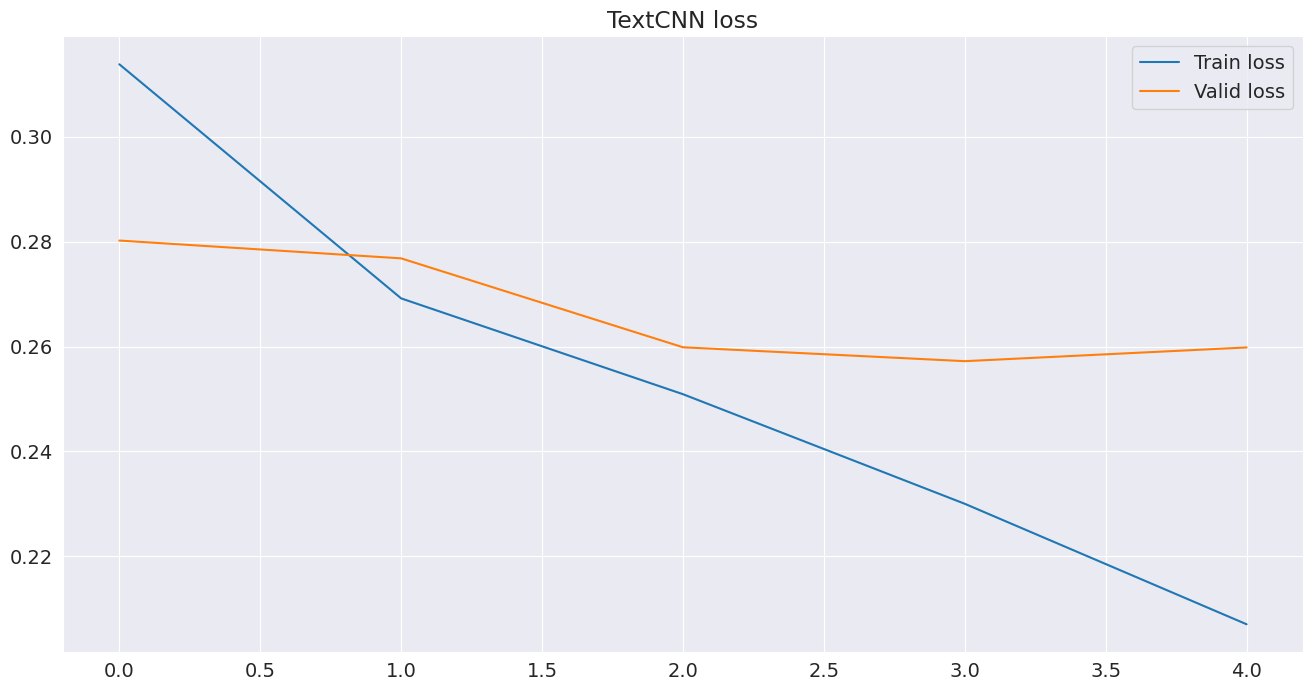

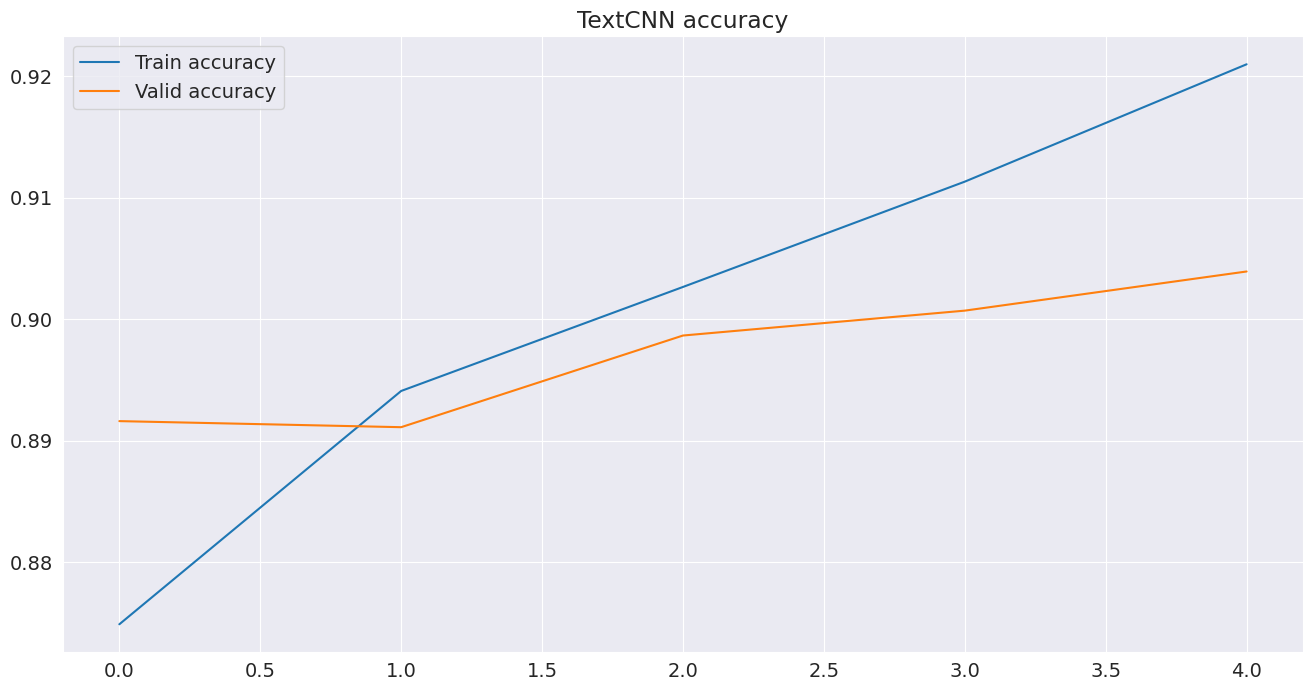

In [39]:
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, NUM_EPOCHS, 'TextCNN', scheduler)